In [2]:


import os
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


print("Ready.")


Ready.


In [3]:


df = pd.read_csv('AIML Dataset.csv')

print("Shape:", df.shape)
display(df.head())


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:


print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["isFraud"].value_counts())

fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.4%}")


Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:


step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Duplicate rows: 0

Target distribution:


isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%


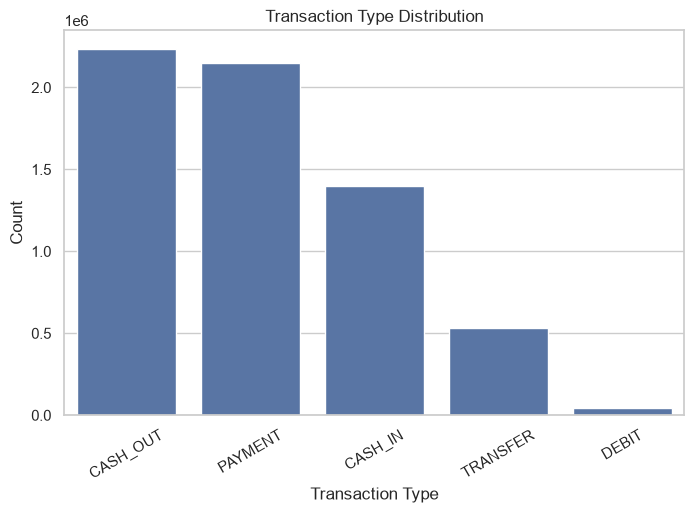

In [5]:


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


In [6]:


fraud_by_type = pd.crosstab(df["type"], df["isFraud"])
display(fraud_by_type)

fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)

fraud_rate_by_type["mean"] *= 100
fraud_rate_by_type.rename(columns={
    "count": "transactions",
    "sum": "fraud_count",
    "mean": "fraud_rate_percent"
}, inplace=True)

display(fraud_rate_by_type)


isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


,transactions,fraud_count,fraud_rate_percent
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


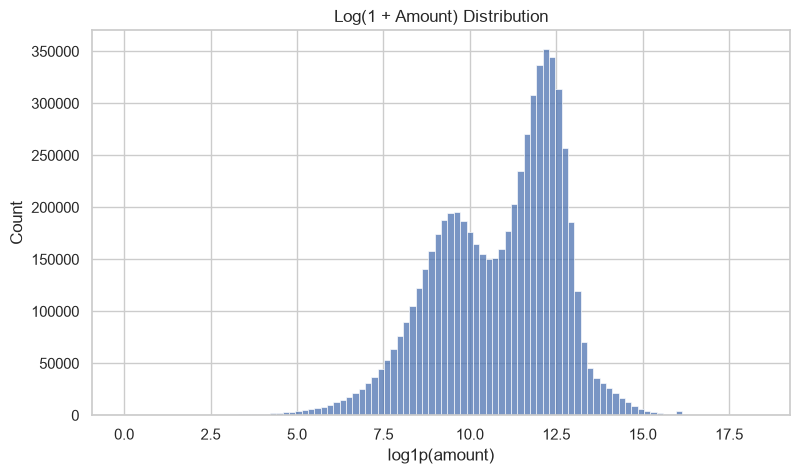

In [7]:


plt.figure(figsize=(9, 5))
sns.histplot(np.log1p(df["amount"]), bins=100)
plt.title("Log(1 + Amount) Distribution")
plt.xlabel("log1p(amount)")
plt.ylabel("Count")
plt.show()


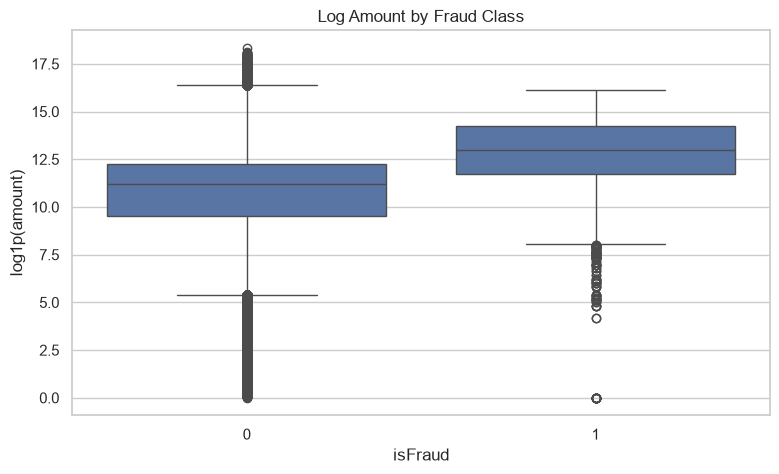

In [8]:
# Fraud amount distribution

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="isFraud", y=np.log1p(df["amount"]))
plt.title("Log Amount by Fraud Class")
plt.xlabel("isFraud")
plt.ylabel("log1p(amount)")
plt.show()


In [9]:

MODEL_INPUT_COLUMNS = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

TARGET = "isFraud"

missing_required = [c for c in MODEL_INPUT_COLUMNS + [TARGET] if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

model_df = df[MODEL_INPUT_COLUMNS + [TARGET]].copy()

print("Model dataframe shape:", model_df.shape)
display(model_df.head())


Model dataframe shape: (6362620, 7)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [10]:


class FraudFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create deterministic fraud-detection features from raw transaction fields."""

    input_columns_ = [
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest"
    ]

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = X.columns.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        required = self.input_columns_
        missing = [c for c in required if c not in X.columns]
        if missing:
            raise ValueError(f"Missing input columns: {missing}")

        # Original account balance change
        X["balanceDiffOrig"] = (
            X["oldbalanceOrg"] - X["newbalanceOrig"]
        )

        # Destination balance change: positive means destination balance increased
        X["balanceDiffDest"] = (
            X["newbalanceDest"] - X["oldbalanceDest"]
        )

        # Expected balance consistency
        X["orig_balance_error"] = (
            X["oldbalanceOrg"]
            - X["amount"]
            - X["newbalanceOrig"]
        )

        X["dest_balance_error"] = (
            X["oldbalanceDest"]
            + X["amount"]
            - X["newbalanceDest"]
        )

        # Ratios with safe denominators
        X["orig_balance_ratio"] = (
            X["amount"] / (X["oldbalanceOrg"] + 1.0)
        )

        X["dest_balance_ratio"] = (
            X["amount"] / (X["oldbalanceDest"] + 1.0)
        )

        # Zero-balance indicators
        X["orig_zero_before"] = (X["oldbalanceOrg"] == 0).astype(int)
        X["orig_zero_after"] = (X["newbalanceOrig"] == 0).astype(int)
        X["dest_zero_before"] = (X["oldbalanceDest"] == 0).astype(int)
        X["dest_zero_after"] = (X["newbalanceDest"] == 0).astype(int)

        # Reduce the extreme skew of transaction amount
        X["amount_log"] = np.log1p(X["amount"].clip(lower=0))

        # Keep all engineered features plus the original model inputs.
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array([
            "type",
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "balanceDiffOrig",
            "balanceDiffDest",
            "orig_balance_error",
            "dest_balance_error",
            "orig_balance_ratio",
            "dest_balance_ratio",
            "orig_zero_before",
            "orig_zero_after",
            "dest_zero_before",
            "dest_zero_after",
            "amount_log"
        ], dtype=object)


In [11]:
# Test feature engineering before training

feature_engineer = FraudFeatureEngineer()
X_engineered_preview = feature_engineer.fit_transform(
    model_df.drop(columns=TARGET).head()
)

print("Engineered columns:")
print(X_engineered_preview.columns.tolist())

display(X_engineered_preview.head())


Engineered columns:
['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'orig_balance_error', 'dest_balance_error', 'orig_balance_ratio', 'dest_balance_ratio', 'orig_zero_before', 'orig_zero_after', 'dest_zero_before', 'dest_zero_after', 'amount_log']


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiffOrig,balanceDiffDest,orig_balance_error,dest_balance_error,orig_balance_ratio,dest_balance_ratio,orig_zero_before,orig_zero_after,dest_zero_before,dest_zero_after,amount_log
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0,0.0,9839.64,0.057834,9839.640000,0,0,1,1,9.194276
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0,0.0,1864.28,0.087731,1864.280000,0,0,1,1,7.531166
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,181.00,0.0,0.0,181.00,0.994505,181.000000,0,1,1,1,5.204007
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0,0.0,21363.00,0.994505,0.008545,0,1,0,1,5.204007
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0,0.0,11668.14,0.280788,11668.140000,0,0,1,1,9.364703


In [12]:


X = model_df.drop(columns=TARGET)
y = model_df[TARGET].astype(int)


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nFraud counts:")
print("Train:")
print(y_train.value_counts())
print("\nValidation:")
print(y_val.value_counts())
print("\nTest:")
print(y_test.value_counts())


Train: (4453834, 6) (4453834,)
Validation: (954393, 6) (954393,)
Test: (954393, 6) (954393,)

Fraud counts:
Train:
isFraud
0    4448085
1       5749
Name: count, dtype: int64

Validation:
isFraud
0    953161
1      1232
Name: count, dtype: int64

Test:
isFraud
0    953161
1      1232
Name: count, dtype: int64


In [13]:


NUMERIC_FEATURES = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceDiffOrig",
    "balanceDiffDest",
    "orig_balance_error",
    "dest_balance_error",
    "orig_balance_ratio",
    "dest_balance_ratio",
    "orig_zero_before",
    "orig_zero_after",
    "dest_zero_before",
    "dest_zero_after",
    "amount_log"
]

CATEGORICAL_FEATURES = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            NUMERIC_FEATURES
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


X_train_fe = feature_engineer.fit_transform(X_train)
X_val_fe = feature_engineer.transform(X_val)
X_test_fe = feature_engineer.transform(X_test)

X_train_processed = preprocessor.fit_transform(X_train_fe)
X_val_processed = preprocessor.transform(X_val_fe)
X_test_processed = preprocessor.transform(X_test_fe)

feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("\nFeatures:")
print(feature_names.tolist())


Processed train shape: (4453834, 21)
Processed validation shape: (954393, 21)
Processed test shape: (954393, 21)

Features:
['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'orig_balance_error', 'dest_balance_error', 'orig_balance_ratio', 'dest_balance_ratio', 'orig_zero_before', 'orig_zero_after', 'dest_zero_before', 'dest_zero_after', 'amount_log', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [14]:


negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)


Negative samples: 4448085
Positive samples: 5749
scale_pos_weight: 773.7145590537485


In [28]:


# xgb_model = XGBClassifier(
#     n_estimators=400,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     min_child_weight=1,
#     gamma=0,
#     reg_alpha=0,
#     reg_lambda=1,
#     scale_pos_weight=scale_pos_weight,
#     objective="binary:logistic",
#     eval_metric="aucpr",
#     tree_method="hist",
#     random_state=RANDOM_STATE,
#     n_jobs=-1
# )

# xgb_model.fit(
#     X_train_processed,
#     y_train,
#     eval_set=[(X_val_processed, y_val)],
#     verbose=False
# )

# print("Model trained.")


from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("features", FraudFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


In [32]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('features', FraudFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balanceDiffOrig',
                                                   'balanceDiffDest',
                                                   'orig_balance_error',
                                                   'dest_balance_error',
                                                   'orig_balance_ratio',
                                                   'dest_balance_ratio',
                                                   'orig_zero_before',
                                                   'orig_zero_af...
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [33]:


y_val_prob = pipeline.predict_proba(X_val)[:, 1]
y_test_prob = pipeline.predict_proba(X_test)[:, 1]

print("Validation PR-AUC:",
      average_precision_score(y_val, y_val_prob))

print("Validation ROC-AUC:",
      roc_auc_score(y_val, y_val_prob))


Validation PR-AUC: 0.9982755231729056
Validation ROC-AUC: 0.9996920090781464


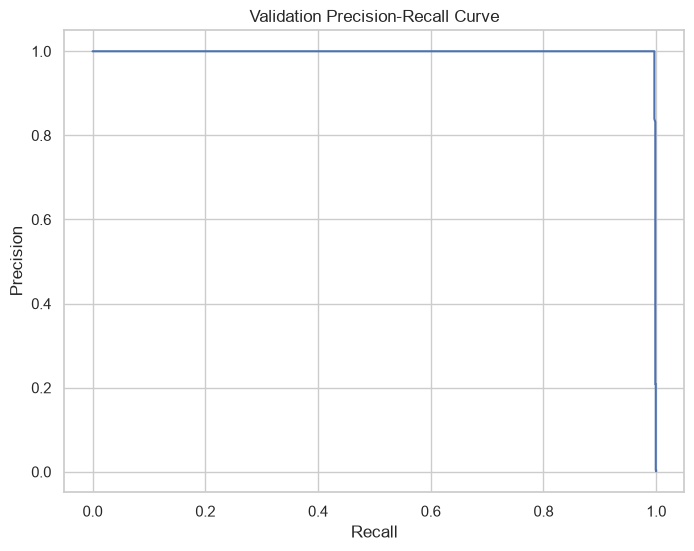

In [34]:


precision, recall, thresholds_pr = precision_recall_curve(
    y_val, y_val_prob
)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve")
plt.grid(True)
plt.show()


In [35]:


thresholds = np.arange(0.05, 1.00, 0.01)

threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision_value = precision_score(
        y_val, y_val_pred, zero_division=0
    )
    recall_value = recall_score(
        y_val, y_val_pred, zero_division=0
    )
    f1_value = f1_score(
        y_val, y_val_pred, zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val, y_val_pred
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_results = pd.DataFrame(threshold_results)

best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

BEST_THRESHOLD = float(best_row["threshold"])

display(best_row.to_frame().T)

print(f"Selected validation threshold: {BEST_THRESHOLD:.2f}")


,threshold,precision,recall,f1,TN,FP,FN,TP
94,0.99,1.0,0.996753,0.998374,953161.0,0.0,4.0,1228.0


Selected validation threshold: 0.99


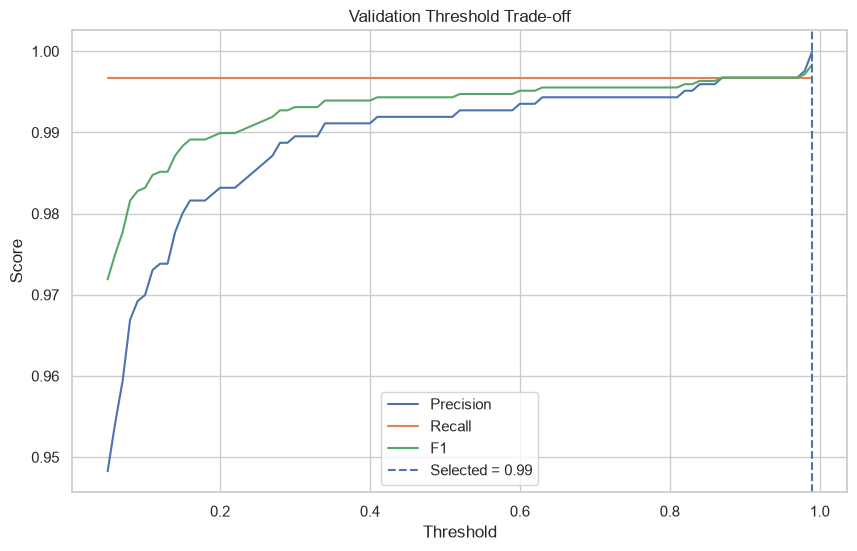

In [36]:


plt.figure(figsize=(10, 6))
plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)
plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)
plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)
plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Selected = {BEST_THRESHOLD:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Trade-off")
plt.legend()
plt.grid(True)
plt.show()


In [37]:


y_val_pred = (y_val_prob >= BEST_THRESHOLD).astype(int)

print("Validation classification report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

val_cm = confusion_matrix(y_val, y_val_pred)

print("Validation confusion matrix:")
print(val_cm)

print("Validation PR-AUC:",
      average_precision_score(y_val, y_val_prob))


Validation classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    953161
       Fraud       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393

Validation confusion matrix:
[[953161      0]
 [     4   1228]]
Validation PR-AUC: 0.9982755231729056


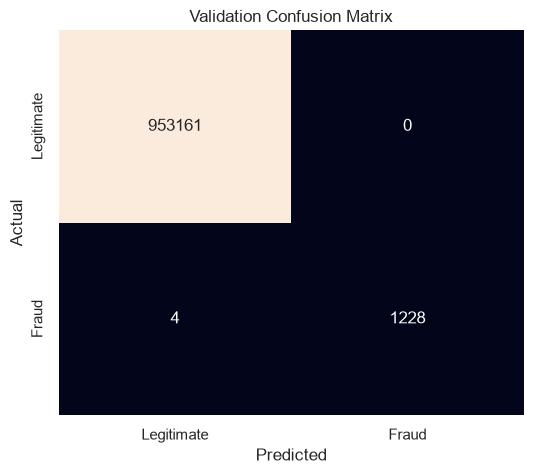

In [38]:


plt.figure(figsize=(6, 5))
sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()


In [39]:


y_test_pred = (y_test_prob >= BEST_THRESHOLD).astype(int)

test_pr_auc = average_precision_score(y_test, y_test_prob)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

test_precision = precision_score(
    y_test, y_test_pred, zero_division=0
)
test_recall = recall_score(
    y_test, y_test_pred, zero_division=0
)
test_f1 = f1_score(
    y_test, y_test_pred, zero_division=0
)

test_cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = test_cm.ravel()

print("===== FINAL TEST RESULTS =====")
print(f"Threshold: {BEST_THRESHOLD:.2f}")
print(f"PR-AUC:    {test_pr_auc:.6f}")
print(f"ROC-AUC:   {test_roc_auc:.6f}")
print(f"Precision: {test_precision:.6f}")
print(f"Recall:    {test_recall:.6f}")
print(f"F1:        {test_f1:.6f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)


===== FINAL TEST RESULTS =====
Threshold: 0.99
PR-AUC:    0.997857
ROC-AUC:   0.999553
Precision: 0.998373
Recall:    0.995942
F1:        0.997156

Confusion Matrix:
[[953159      2]
 [     5   1227]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    953161
       Fraud       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393



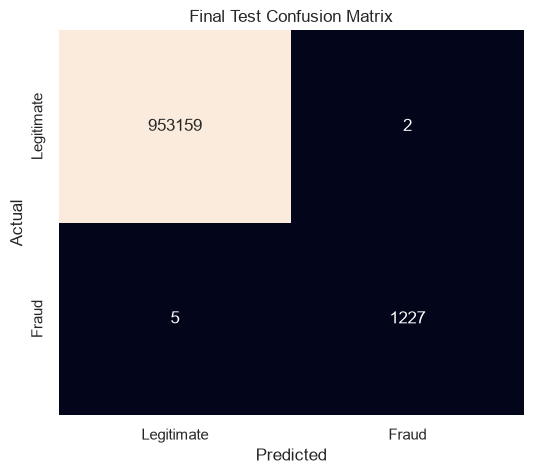

In [40]:


plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Test Confusion Matrix")
plt.show()


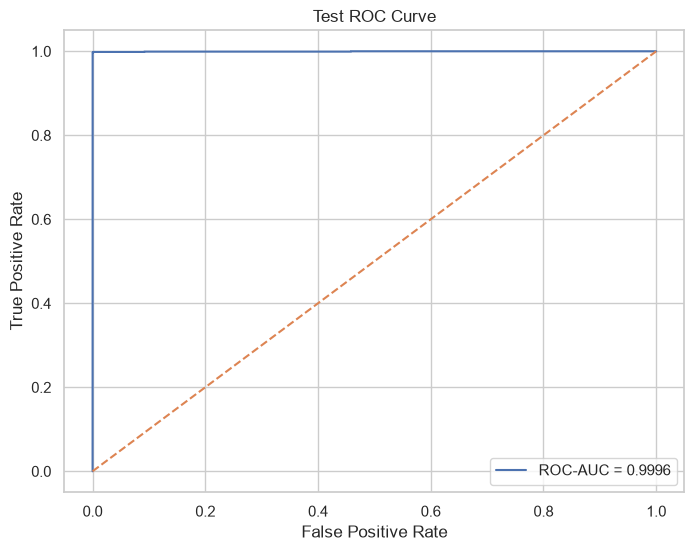

In [41]:


fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


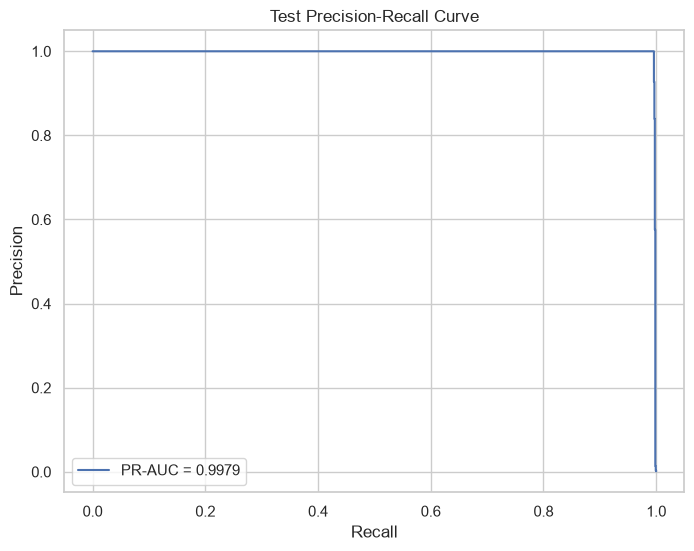

In [42]:


test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test, y_test_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    test_recall_curve,
    test_precision_curve,
    label=f"PR-AUC = {test_pr_auc:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


,feature,importance
12,orig_zero_after,0.284892
7,orig_balance_error,0.210511
5,balanceDiffOrig,0.196498
14,dest_zero_after,0.124246
2,newbalanceOrig,0.079773
9,orig_balance_ratio,0.028432
20,type_TRANSFER,0.014128
0,amount,0.013961
17,type_CASH_OUT,0.011569
15,amount_log,0.008544


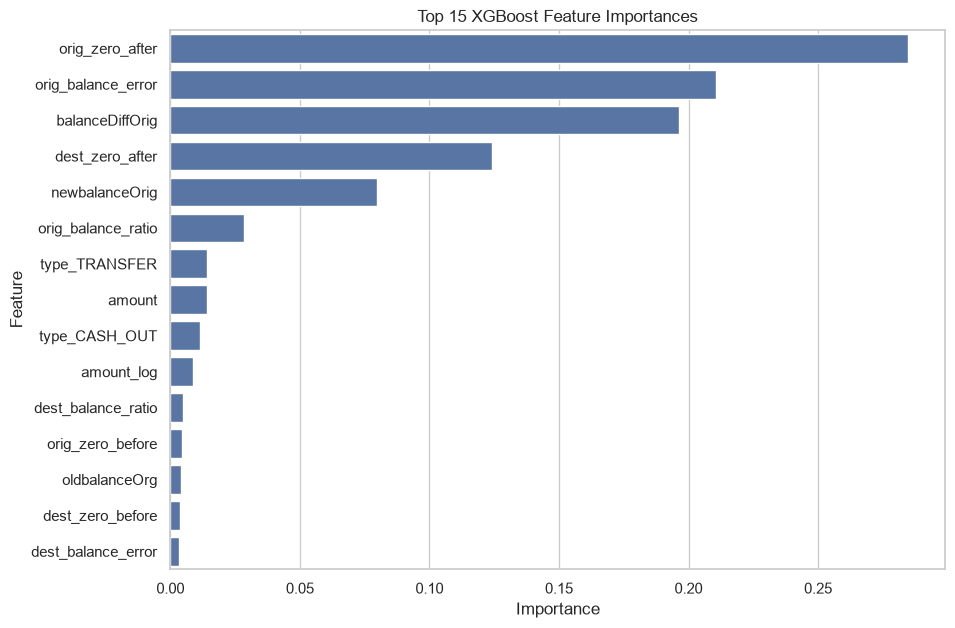

In [44]:
# importance_df = pd.DataFrame({
#     "feature": feature_names,
#     "importance": pipeline.feature_importances_
# }).sort_values("importance", ascending=False)

# display(importance_df.head(20))

# plt.figure(figsize=(10, 7))
# sns.barplot(
#     data=importance_df.head(15),
#     x="importance",
#     y="feature"
# )
# plt.title("Top 15 XGBoost Feature Importances")
# plt.xlabel("Importance")
# plt.ylabel("Feature")
# plt.show()



# Get the fitted XGBoost model from the pipeline
xgb_model_fitted = pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Create importance dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model_fitted.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [47]:


sample_transaction = pd.DataFrame([{
    "type": "TRANSFER",
    "amount": 100000.0,
    "oldbalanceOrg": 100000.0,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 0.0
}])

# sample_fe = feature_engineer.transform(sample_transaction)
# sample_processed = preprocessor.transform(sample_fe)

sample_probability = float(
    pipeline.predict_proba(sample_transaction)[0, 1]
)

sample_prediction = int(
    sample_probability >= BEST_THRESHOLD
)

print("Fraud probability:", sample_probability)
print("Prediction:", "Fraud" if sample_prediction else "Legitimate")


Fraud probability: 0.9999992847442627
Prediction: Fraud


In [48]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    pipeline,
    "artifacts/fraud_pipeline.joblib"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [49]:
import json

with open("artifacts/metadata.json", "w") as f:
    json.dump({
        "threshold": float(BEST_THRESHOLD)
    }, f, indent=4)

print("Threshold saved:", BEST_THRESHOLD)

Threshold saved: 0.9900000000000002


In [50]:
loaded_pipeline = joblib.load(
    "artifacts/fraud_pipeline.joblib"
)

with open("artifacts/metadata.json", "r") as f:
    metadata = json.load(f)

loaded_threshold = metadata["threshold"]

probability = float(
    loaded_pipeline.predict_proba(sample_transaction)[0, 1]
)

prediction = int(probability >= loaded_threshold)

print("Probability:", probability)
print("Prediction:", "Fraud" if prediction else "Legitimate")

Probability: 0.9999992847442627
Prediction: Fraud


In [ ]:


ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(
    feature_engineer,
    ARTIFACT_DIR / "feature_engineer.joblib"
)

joblib.dump(
    preprocessor,
    ARTIFACT_DIR / "preprocessor.joblib"
)

joblib.dump(
    xgb_model,
    ARTIFACT_DIR / "xgb_model.joblib"
)

metadata = {
    "model_name": "XGBoost Fraud Detection",
    "random_state": RANDOM_STATE,
    "threshold": BEST_THRESHOLD,
    "input_columns": MODEL_INPUT_COLUMNS,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "test_pr_auc": float(test_pr_auc),
    "test_roc_auc": float(test_roc_auc),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1)
}

with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved:")
for path in ARTIFACT_DIR.iterdir():
    print(" -", path)


In [ ]:


loaded_feature_engineer = joblib.load(
    ARTIFACT_DIR / "feature_engineer.joblib"
)

loaded_preprocessor = joblib.load(
    ARTIFACT_DIR / "preprocessor.joblib"
)

loaded_model = joblib.load(
    ARTIFACT_DIR / "xgb_model.joblib"
)

with open(ARTIFACT_DIR / "metadata.json", "r") as f:
    loaded_metadata = json.load(f)

reload_fe = loaded_feature_engineer.transform(sample_transaction)
reload_processed = loaded_preprocessor.transform(reload_fe)

reload_probability = float(
    loaded_model.predict_proba(reload_processed)[0, 1]
)

reload_prediction = int(
    reload_probability >= loaded_metadata["threshold"]
)

print("Original probability:", sample_probability)
print("Reloaded probability:", reload_probability)
print("Same probability:",
      np.isclose(sample_probability, reload_probability))

print(
    "Reloaded prediction:",
    "Fraud" if reload_prediction else "Legitimate"
)
